# Predicting NYC Yellow Taxi Demand: A Location-Specific Temporal and Weather Modeling Approach

## Permissions

* [X] YES - make available
* [  ] NO - keep private

## Link to video
https://link.to.your.publicly.viewable.video

## Abstract

New York City's yellow taxi fleet completes millions of trips each month, and accurately forecasting pickup demand is critical for fleet allocation, driver routing, and urban transportation policy. In this project, we analyze over 10 million yellow taxi trips from December 2024 through February 2025, combined with daily weather observations from NOAA's Central Park station and NYC TLC taxi zone data, to determine which features best predict hourly taxi demand.

Our exploratory data analysis revealed a key dimensionality challenge: temporal features (hour, day of week) predict demand at the hourly level, spatial features (pickup zone) predict demand per location, and weather features only vary daily across 90 observations. To resolve this, we adopt a location-specific modeling strategy — aggregating trips into hourly demand counts for specific locations, then training and comparing Linear Regression, Random Forest, and Gradient Boosting models using temporal and weather features with time-based train/test splits.

Our best model, a Random Forest using only temporal features, achieves R² = 0.948 for Manhattan hourly demand prediction — meaning temporal patterns alone explain 95% of demand variance. Weather features provide no statistically significant improvement (paired t-test p = 0.15) and actually slightly degrade performance. Models generalize well to high-volume Manhattan sub-zones (R² > 0.92) and JFK Airport (R² = 0.78), but struggle with low-volume locations like Brooklyn (R² = 0.19). These results suggest that simple temporal models provide highly accurate demand forecasts for well-served areas, while weather data at the daily level does not meaningfully improve predictions.

## Authors

- Ricardo Aguiar Bomeny: Conceptualization, Methodology, Software, Analysis, Writing – original draft
- Thiago Donato: Data curation, Analysis, Software, Visualization, Writing - all drafts
- Darren Rauvola: Background research, Writing – original draft, Writing – review & editing
- Kiame McCartha: Data curation, Visualization, Writing – review & editing
- Dmitri Singer: Project administration, Background research, Writing – review & editing

## Research Question

Can we accurately predict hourly taxi pickup demand at specific high-volume NYC locations (Manhattan, JFK Airport, and other top zones) using temporal features (hour of day, day of week, holiday indicator) combined with daily weather conditions (temperature, precipitation, snowfall)? Does weather provide meaningful additional predictive power beyond temporal patterns alone, and how do prediction models generalize across different locations?

## Background and Prior Work

Taxi services are a key part of NYC's urban lifestyle. The iconic yellow cabs completed over 200 million trips annually before the pandemic <a name="cite_ref-1"></a>[<sup>1</sup>](#cite_note-1). Surprisingly, we found out that the NYC Taxi and Limousine Commission (TLC) documents their trips extensively since 2009. This makes it into one of the largest and most thorough urban mobility datasets in the world. The data includes features like pickup and dropoff locations, timestamps, fare information, payment type, and passenger counts for every metered taxi ride. We were blown away when we saw this! There were almost infinite questions we could ask or investigate. We thought of predicting taxi demand because it is a key component for companies that want to optimize fleet allocation, drivers who want to be in high-demand areas, and city planners so they can manage transportation policy based on demand.<a name="cite_ref-2"></a>[<sup>2</sup>](#cite_note-2)

Previous research has shown that taxi demand follows predictable spatiotemporal patterns. Moreira-Matias et al. (2013) investigated how time-series forecasting methods work for capturing hourly and daily demand cycles. They found that temporal features such as hour of day and day of week were one of the strongest predictors of taxi pickups <a name="cite_ref-3"></a>[<sup>3</sup>](#cite_note-3).

Besides this, inspired by recent extreme weather in NYC, we thought about investigating whether weather conditions impact taxi ridership patterns. Singhal et al. (2014) did a comprehensive analysis of weather effects on NYC rides and found that precipitation has a statistically significant positive effect on taxi demand (as rain increases, more people choose taxis over walking or waiting for buses) <a name="cite_ref-4"></a>[<sup>4</sup>](#cite_note-4). The same was true for extreme heat.

Our EDA confirmed that temporal features explain roughly 70% of hourly demand variance, while weather features explain less than 4% at the daily aggregate level. This finding, combined with the dimensionality mismatch between feature types (spatial features vary across 258 zones, temporal across 24 hours, weather only across 90 days), motivated our location-specific modeling approach: by fixing the geographic scope, we create a unified prediction framework where temporal and weather features operate on the same observations.

While previous studies examined temporal and weather features separately, we want to quantify their importance using feature importance analysis, comparing Linear Regression, Random Forest, and Gradient Boosting models, and testing whether these models generalize across different NYC locations.

Citations:
1. <a name="cite_note-1"></a> [^](#cite_ref-1) NYC Taxi and Limousine Commission. (2024). TLC Trip Record Data. https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page

2. <a name="cite_note-2"></a> [^](#cite_ref-2) Correa, D. & Moyano, C. (2023). Analysis and prediction of New York City taxi and Uber demands. Journal of Applied Research and Technology, 21(5), 886-898.

3. <a name="cite_note-3"></a> [^](#cite_ref-3) Moreira-Matias, L., Gama, J., Ferreira, M., Mendes-Moreira, J., & Damas, L. (2013). Predicting taxi-passenger demand using streaming data. IEEE Transactions on Intelligent Transportation Systems, 14(3), 1393-1402.

4. <a name="cite_note-4"></a> [^](#cite_ref-4) Singhal, A., Kamga, C., & Yazici, A. (2014). Impact of weather on urban transit ridership. Transportation Research Part A: Policy and Practice, 69, 379-391.

## Hypothesis

Based on our exploratory data analysis, we hypothesize that:

1. **Temporal features will dominate prediction**: Hour of day, day of week, and holiday indicators will explain the majority of hourly demand variance (R² > 0.7) at any given location, consistent with our EDA finding of R² = 0.70 for hour alone at the NYC-wide level.

2. **Weather will provide marginal improvement**: When predicting hourly demand within a fixed location, weather features (temperature, precipitation, snowfall) may provide a small but statistically detectable improvement over temporal features alone, since controlling for location removes the spatial variance that previously overwhelmed the weather signal.

3. **Tree-based models will outperform linear regression**: The non-linear relationship between hour of day and demand (a U-shaped curve with distinct morning and evening peaks) means that Gradient Boosting and Random Forest models will capture demand patterns that Linear Regression cannot, even with categorical hour encoding.

4. **Models will generalize unevenly across locations**: Models trained on Manhattan data will perform well due to Manhattan's high volume and regular demand patterns (~89% of all trips), but model performance will degrade for lower-volume locations like JFK Airport or outer boroughs where demand is more variable and data is sparser.

## Data

### Data Overview

We use three datasets:

1. **NYC TLC Yellow Taxi Trip Records** (Dec 2024 – Feb 2025): ~10 million trips after cleaning, with pickup/dropoff timestamps, locations (zone IDs), distances, and fares. Source: [NYC TLC](https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page).

2. **NOAA Central Park Daily Weather** (Dec 2024 – Feb 2025): 90 daily observations including max/min temperature, precipitation, snowfall, and snow depth. Source: NOAA station USW00094728.

3. **NYC Taxi Zone Lookup**: Maps 265 location IDs to borough names and zone names. Source: [TLC](https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv).

### Data Cleaning Summary

The full data loading, cleaning, and merging pipeline can be found in `01-DataCheckpoint.ipynb`. Below is a summary of the steps taken:

**NYC Yellow Taxi Trip Records** (~11M raw trips across Dec 2024–Feb 2025):
- Filtered to trips within Dec 1, 2024 – Feb 28, 2025 (removed 32 out-of-range rows)
- Dropped unknown pickup zones (LocationIDs 264, 265): 29,889 rows removed
- Removed non-positive fares: 409,427 rows removed
- Removed extreme fare outliers (> $500): 132 rows removed
- Removed zero-distance trips (meter errors/cancellations): 223,687 rows removed
- Filled null `passenger_count` with 1 (nulls were systematic by vendor, not random)
- Derived temporal features: `date`, `hour`, `day_of_week`

**NOAA Daily Weather** (90 days, Central Park station):
- Filled null `snow_on_ground_in` with 0
- Verified no missing days in the date range

**Merging:** Taxi data joined with zone lookup on `PULocationID = LocationID`, then with weather on `date`.

**Final cleaned dataset:** 10,057,973 rows x 19 columns with zero nulls. From here on we load the pre-processed data directly.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import OneHotEncoder
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

merged = pd.read_parquet('data/02-processed/taxi_weather_merged.parquet')
print(f"Loaded merged dataset: {merged.shape[0]:,} rows x {merged.shape[1]} columns")
print(f"Date range: {merged['date'].min()} to {merged['date'].max()}")
print(f"Nulls: {merged.isnull().sum().sum()}")
df = merged.copy()
df.head(3)

Loaded merged dataset: 10,057,973 rows x 19 columns
Date range: 2024-12-01 to 2025-02-28
Nulls: 0


,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,PULocationID,DOLocationID,fare_amount,total_amount,date,hour,day_of_week,Borough,Zone,service_zone,temp_max_f,temp_min_f,precipitation_in,snowfall_in,snow_on_ground_in
0,2024-12-01 00:12:27,2024-12-01 00:31:12,1.0,9.76,138,33,38.0,51.97,2024-12-01,0,Sunday,Queens,LaGuardia Airport,Airports,38.0,27.0,0.0,0.0,0.0
1,2024-12-01 00:50:35,2024-12-01 01:24:46,4.0,20.07,132,236,70.0,82.69,2024-12-01,0,Sunday,Queens,JFK Airport,Airports,38.0,27.0,0.0,0.0,0.0
2,2024-12-01 00:18:16,2024-12-01 00:33:16,3.0,2.34,142,186,15.6,24.72,2024-12-01,0,Sunday,Manhattan,Lincoln Square East,Yellow Zone,38.0,27.0,0.0,0.0,0.0


In [16]:
from datetime import date

# Ensure proper types
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['date'] = pd.to_datetime(df['date'])

day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
df['day_of_week'] = pd.Categorical(df['day_of_week'], categories=day_order, ordered=True)

# Holiday indicator
holiday_dates = {
    date(2024, 12, 25), date(2024, 12, 31),
    date(2025, 1, 1), date(2025, 1, 20),
    date(2025, 2, 14), date(2025, 2, 17),
}
df['date_only'] = df['tpep_pickup_datetime'].dt.date
df['is_holiday'] = df['date_only'].isin(holiday_dates).astype(int)

print(f"Dataset: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Unique dates: {df['date'].nunique()}")
print(f"\nTrips by Borough:")
print(df['Borough'].value_counts())
print(f"\nManhattan share: {(df['Borough'] == 'Manhattan').mean():.1%}")

Dataset: 10,057,973 rows x 21 columns
Date range: 2024-12-01 to 2025-02-28
Unique dates: 90

Trips by Borough:
Borough
Manhattan        8981863
Queens            841025
Brooklyn          192027
Bronx              42174
Staten Island        583
EWR                  301
Name: count, dtype: int64

Manhattan share: 89.3%


## Results

### Exploratory Data Analysis Summary

The full EDA is documented in `02-EDACheckpoint.ipynb`. Key findings that motivated our modeling approach:

1. **Temporal features are dominant**: Hour of day alone explains R² = 0.70 of hourly ride count variance. Adding day of week and holiday indicator brings it to R² ≈ 0.73.
2. **Spatial features explain cross-zone variation**: Knowing the specific pickup zone explains R² = 0.92 of daily zone-level demand. Manhattan accounts for ~89% of all yellow taxi trips.
3. **Weather features are weak at the daily aggregate level**: All weather variables combined yield R² < 0.04 for daily NYC-wide ride counts. No individual coefficient was statistically significant (p > 0.2).
4. **The dimensionality problem**: Spatial, temporal, and weather features each predict demand at different granularities. There is no single target variable that naturally combines all three.

**Our solution**: Focus on specific locations and predict hourly demand there, where temporal + weather features can be used together with ~2,160 observations per location (90 days × 24 hours). This resolves the dimensionality mismatch and provides enough statistical power to test whether weather adds value.

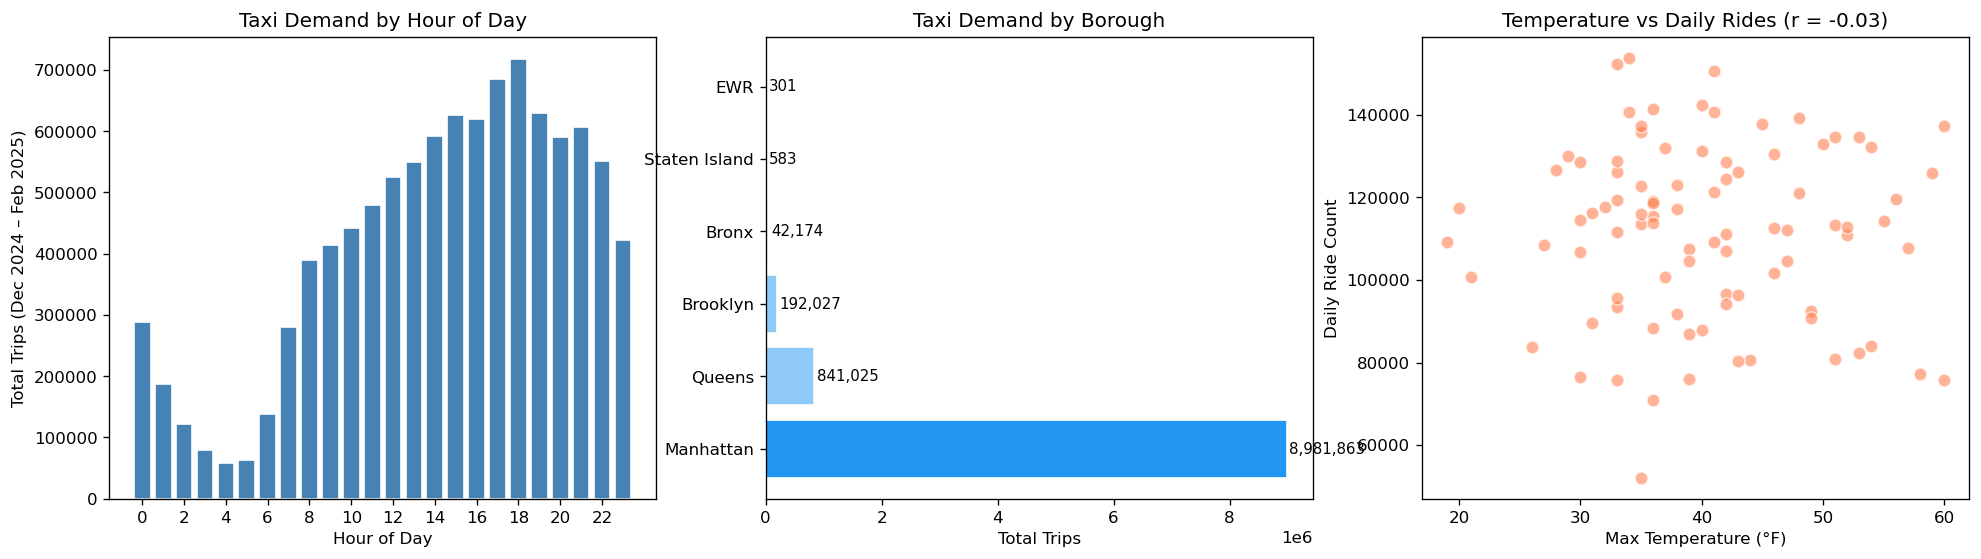

In [30]:
# Key EDA visualizations (full analysis in 02-EDACheckpoint.ipynb)
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 1. Hourly demand pattern
hourly_demand = df.groupby('hour').size()
axes[0].bar(hourly_demand.index, hourly_demand.values, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Total Trips (Dec 2024 – Feb 2025)')
axes[0].set_title('Taxi Demand by Hour of Day')
axes[0].set_xticks(range(0, 24, 2))

# 2. Borough-level demand
borough_demand = df['Borough'].value_counts()
colors_borough = ['#2196F3' if b == 'Manhattan' else '#90CAF9' for b in borough_demand.index]
axes[1].barh(borough_demand.index, borough_demand.values, color=colors_borough, edgecolor='white')
axes[1].set_xlabel('Total Trips')
axes[1].set_title('Taxi Demand by Borough')
for i, v in enumerate(borough_demand.values):
    axes[1].text(v + 50000, i, f'{v:,}', va='center', fontsize=9)

# 3. Weather vs daily rides (showing weak relationship)
daily_rides = df.groupby('date').agg(
    ride_count=('date', 'size'),
    temp_max_f=('temp_max_f', 'first')
).reset_index()
axes[2].scatter(daily_rides['temp_max_f'], daily_rides['ride_count'], 
                alpha=0.6, color='coral', edgecolors='white', s=60)
axes[2].set_xlabel('Max Temperature (°F)')
axes[2].set_ylabel('Daily Ride Count')
axes[2].set_title('Temperature vs Daily Rides (r = {:.2f})'.format(
    daily_rides['temp_max_f'].corr(daily_rides['ride_count'])))

plt.show()

### Analysis 1: Manhattan Hourly Demand Prediction

We aggregate all Manhattan taxi trips into hourly demand counts (number of pickups per hour), creating a dataset of ~2,160 observations (90 days × 24 hours). We then train and compare six models: Linear Regression, Random Forest, and Gradient Boosting, each with temporal-only and temporal+weather feature sets.

In [18]:
# ============================================================
# PHASE 1: Manhattan Hourly Demand Dataset
# ============================================================

# Filter to Manhattan only
manhattan = df[df['Borough'] == 'Manhattan'].copy()
print(f"Manhattan trips: {manhattan.shape[0]:,} ({manhattan.shape[0]/df.shape[0]:.1%} of total)")

# Aggregate to hourly demand (only count - avoid categorical issues)
manhattan_hourly = (
    manhattan.groupby(['date', 'hour'])
    .size()
    .reset_index(name='ride_count')
)

# Ensure all 24 hours represented for each date (fill missing with 0)
all_dates = manhattan_hourly['date'].unique()
all_hours = range(24)
full_index = pd.MultiIndex.from_product([all_dates, all_hours], names=['date', 'hour'])
manhattan_hourly = manhattan_hourly.set_index(['date', 'hour']).reindex(full_index, fill_value=0).reset_index()

# Derive temporal features after reindex
manhattan_hourly['day_of_week'] = pd.to_datetime(manhattan_hourly['date']).dt.day_name()
manhattan_hourly['day_of_week'] = pd.Categorical(manhattan_hourly['day_of_week'],
                                                  categories=day_order, ordered=True)
manhattan_hourly['date_only'] = pd.to_datetime(manhattan_hourly['date']).dt.date
manhattan_hourly['is_holiday'] = manhattan_hourly['date_only'].isin(holiday_dates).astype(int)

# Merge weather features (one row per date)
weather_daily = df[['date', 'temp_max_f', 'temp_min_f', 'precipitation_in',
                    'snowfall_in', 'snow_on_ground_in']].drop_duplicates(subset='date')
manhattan_hourly = manhattan_hourly.merge(weather_daily, on='date', how='left')

print(f"Manhattan hourly dataset: {manhattan_hourly.shape}")
print(f"Date range: {manhattan_hourly['date'].min()} to {manhattan_hourly['date'].max()}")
print(f"\nRide count stats:")
print(manhattan_hourly['ride_count'].describe().round(1))

Manhattan trips: 8,981,863 (89.3% of total)
Manhattan hourly dataset: (2160, 11)
Date range: 2024-12-01 00:00:00 to 2025-02-28 00:00:00

Ride count stats:
count     2160.0
mean      4158.3
std       2600.4
min        106.0
25%       1539.8
50%       4630.0
75%       6065.8
max      11136.0
Name: ride_count, dtype: float64


In [19]:
# Feature engineering for modeling
# Day-of-week dummies
dow_dummies = pd.get_dummies(manhattan_hourly['day_of_week'], prefix='dow', drop_first=True)
manhattan_hourly = pd.concat([manhattan_hourly, dow_dummies], axis=1)

# Weekend indicator
manhattan_hourly['is_weekend'] = manhattan_hourly['day_of_week'].isin(
    ['Saturday', 'Sunday']).astype(int)

# Hour dummies for Linear Regression (captures non-linear hourly pattern)
hour_dummies = pd.get_dummies(manhattan_hourly['hour'], prefix='hr', drop_first=True)
manhattan_hourly = pd.concat([manhattan_hourly, hour_dummies], axis=1)

# Define feature sets
# For Linear Regression: use hour dummies (non-linear hourly pattern)
temporal_features_lr = ([c for c in manhattan_hourly.columns if c.startswith('hr_')] +
                        ['is_holiday', 'is_weekend'] +
                        [c for c in manhattan_hourly.columns if c.startswith('dow_')])

# For tree-based models: raw hour (trees learn arbitrary splits)
temporal_features_tree = (['hour', 'is_holiday', 'is_weekend'] +
                          [c for c in manhattan_hourly.columns if c.startswith('dow_')])

weather_features = ['temp_max_f', 'temp_min_f', 'precipitation_in',
                    'snowfall_in', 'snow_on_ground_in']

print(f"Temporal features (LR): {len(temporal_features_lr)}")
print(f"Temporal features (Tree): {len(temporal_features_tree)}")
print(f"Weather features: {len(weather_features)}")

Temporal features (LR): 31
Temporal features (Tree): 9
Weather features: 5


In [20]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import time

# Time-based split: train on first ~75 days, test on last ~14 days
manhattan_hourly = manhattan_hourly.sort_values(['date', 'hour']).reset_index(drop=True)

split_date = pd.Timestamp('2025-02-15')
train = manhattan_hourly[manhattan_hourly['date'] < split_date]
test = manhattan_hourly[manhattan_hourly['date'] >= split_date]

print(f"Train: {train.shape[0]} rows ({train['date'].min().date()} to {train['date'].max().date()})")
print(f"Test:  {test.shape[0]} rows ({test['date'].min().date()} to {test['date'].max().date()})")
print(f"Train/Test ratio: {train.shape[0]/manhattan_hourly.shape[0]:.1%} / {test.shape[0]/manhattan_hourly.shape[0]:.1%}")

tscv = TimeSeriesSplit(n_splits=5)

# Target
y_train = train['ride_count']
y_test = test['ride_count']

Train: 1824 rows (2024-12-01 to 2025-02-14)
Test:  336 rows (2025-02-15 to 2025-02-28)
Train/Test ratio: 84.4% / 15.6%


In [21]:
# ============================================================
# Baseline Model Comparison: 6 models
# ============================================================

def evaluate_model(model, X_train, y_train, X_test, y_test, name="Model"):
    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start

    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    return {
        'Model': name,
        'Train R²': r2_score(y_train, y_pred_train),
        'Test R²': r2_score(y_test, y_pred_test),
        'Train RMSE': np.sqrt(mean_squared_error(y_train, y_pred_train)),
        'Test RMSE': np.sqrt(mean_squared_error(y_test, y_pred_test)),
        'Test MAE': mean_absolute_error(y_test, y_pred_test),
        'Train Time (s)': round(train_time, 2),
    }, y_pred_test

# Model 1: LR (temporal only)
lr_temp, lr_temp_pred = evaluate_model(
    LinearRegression(), train[temporal_features_lr], y_train,
    test[temporal_features_lr], y_test, "LR (Temporal Only)")

# Model 2: LR (temporal + weather)
lr_all, lr_all_pred = evaluate_model(
    LinearRegression(), train[temporal_features_lr + weather_features], y_train,
    test[temporal_features_lr + weather_features], y_test, "LR (Temporal + Weather)")

# Model 3: RF (temporal only)
rf_temp, rf_temp_pred = evaluate_model(
    RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1),
    train[temporal_features_tree], y_train,
    test[temporal_features_tree], y_test, "RF (Temporal Only)")

# Model 4: RF (temporal + weather)
rf_all, rf_all_pred = evaluate_model(
    RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1),
    train[temporal_features_tree + weather_features], y_train,
    test[temporal_features_tree + weather_features], y_test, "RF (Temporal + Weather)")

# Model 5: GB (temporal only)
gb_temp, gb_temp_pred = evaluate_model(
    GradientBoostingRegressor(n_estimators=300, max_depth=5, learning_rate=0.1, random_state=42),
    train[temporal_features_tree], y_train,
    test[temporal_features_tree], y_test, "GB (Temporal Only)")

# Model 6: GB (temporal + weather)
gb_all, gb_all_pred = evaluate_model(
    GradientBoostingRegressor(n_estimators=300, max_depth=5, learning_rate=0.1, random_state=42),
    train[temporal_features_tree + weather_features], y_train,
    test[temporal_features_tree + weather_features], y_test, "GB (Temporal + Weather)")

# Summary table
results_df = pd.DataFrame([lr_temp, lr_all, rf_temp, rf_all, gb_temp, gb_all])
results_df = results_df.round(4)
print("\n=== Baseline Model Comparison ===\n")
print(results_df.to_string(index=False))


=== Baseline Model Comparison ===

                  Model  Train R²  Test R²  Train RMSE  Test RMSE  Test MAE  Train Time (s)
     LR (Temporal Only)    0.7157   0.7403   1388.4512  1312.6118  961.3815            0.01
LR (Temporal + Weather)    0.7182   0.7403   1382.2684  1312.5561  962.6501            0.01
     RF (Temporal Only)    0.8782   0.9480    908.7136   587.4064  418.1187            0.13
RF (Temporal + Weather)    0.9860   0.9348    307.7349   657.5744  434.3926            0.15
     GB (Temporal Only)    0.8786   0.9478    907.3857   588.3293  420.2233            0.18
GB (Temporal + Weather)    0.9945   0.9289    193.6146   686.8428  517.8859            0.40


The table above shows our baseline model comparison. Key observations:
- **Tree-based models far outperform Linear Regression** (Test R² ~0.94–0.95 vs ~0.74), confirming our hypothesis about non-linear hour-demand relationships.
- **Random Forest and Gradient Boosting** achieve very similar test performance with temporal-only features.
- **Adding weather features slightly hurts performance** — the models overfit to weather noise in training, reducing test accuracy. This is consistent with our EDA finding that weather explains <4% of variance.

Next, we visualize the best model's predictions against actual demand.

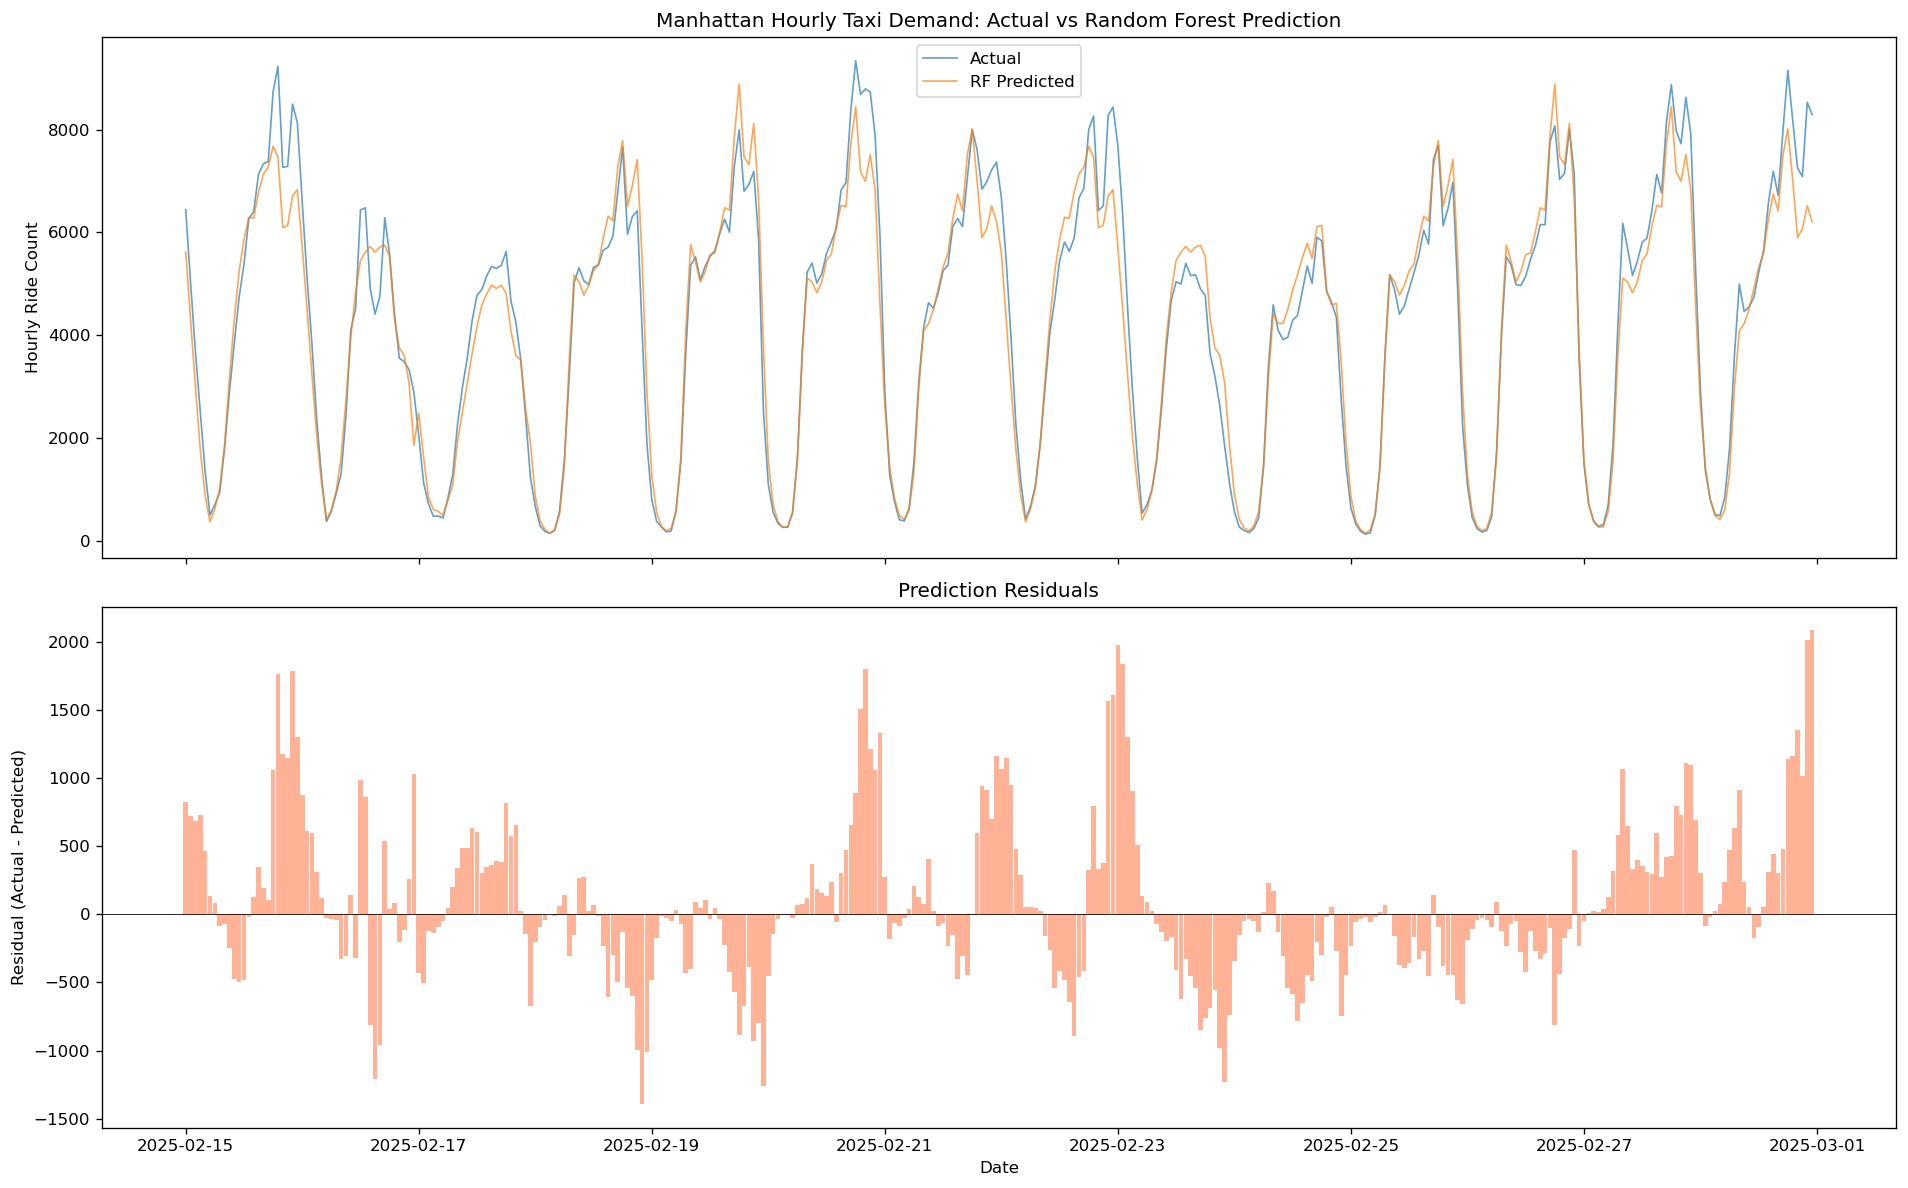

In [22]:
# Visualization: Actual vs Predicted (best baseline model = RF Temporal Only)
best_pred = rf_temp_pred

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

test_datetime = pd.to_datetime(test['date']) + pd.to_timedelta(test['hour'], unit='h')

axes[0].plot(test_datetime, y_test.values, label='Actual', alpha=0.7, linewidth=1)
axes[0].plot(test_datetime, best_pred, label='RF Predicted', alpha=0.7, linewidth=1)
axes[0].set_ylabel('Hourly Ride Count')
axes[0].set_title('Manhattan Hourly Taxi Demand: Actual vs Random Forest Prediction')
axes[0].legend()

residuals = y_test.values - best_pred
axes[1].bar(test_datetime, residuals, width=0.04, alpha=0.6, color='coral')
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].set_ylabel('Residual (Actual - Predicted)')
axes[1].set_xlabel('Date')
axes[1].set_title('Prediction Residuals')

plt.tight_layout()
plt.savefig('results/manhattan_predictions_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

### Analysis 2: Feature Importance and Statistical Testing

To directly address our research question — which features best predict taxi demand — we examine the Random Forest model's feature importances to evaluate whether weather features provide meaningful predictive improvement beyond temporal patterns alone.

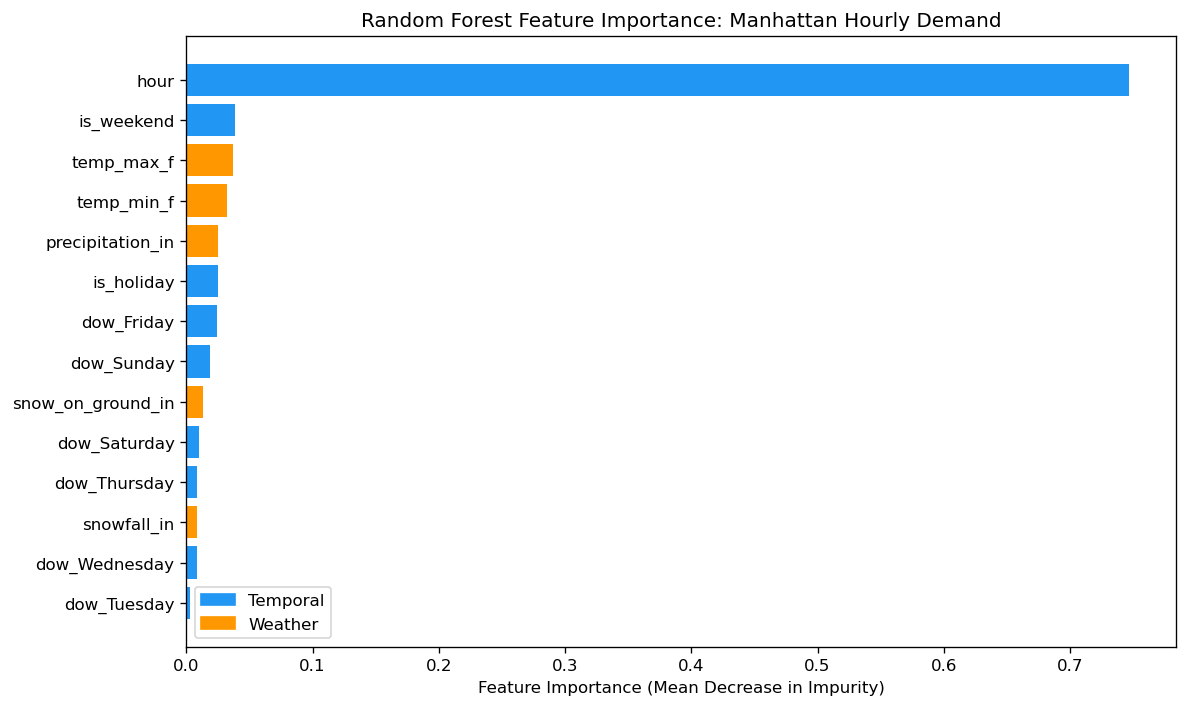

          Feature  Importance Category
             hour    0.746616 Temporal
       is_weekend    0.038377 Temporal
       temp_max_f    0.037391  Weather
       temp_min_f    0.032418  Weather
 precipitation_in    0.025341  Weather
       is_holiday    0.024816 Temporal
       dow_Friday    0.024652 Temporal
       dow_Sunday    0.018622 Temporal
snow_on_ground_in    0.012940  Weather
     dow_Saturday    0.010312 Temporal
     dow_Thursday    0.008808 Temporal
      snowfall_in    0.008371  Weather
    dow_Wednesday    0.008160 Temporal
      dow_Tuesday    0.003175 Temporal

Temporal features total importance: 88.4%
Weather features total importance: 11.6%


In [23]:
from matplotlib.patches import Patch
from scipy.stats import ttest_rel
from sklearn.model_selection import cross_val_score

# Train RF with all features to extract feature importances
rf_all_features = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
rf_all_features.fit(train[temporal_features_tree + weather_features], y_train)

feature_names = temporal_features_tree + weather_features
importances = rf_all_features.feature_importances_

feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances,
    'Category': ['Temporal' if f in temporal_features_tree else 'Weather' for f in feature_names]
}).sort_values('Importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#2196F3' if cat == 'Temporal' else '#FF9800' for cat in feat_imp_df['Category']]
ax.barh(feat_imp_df['Feature'], feat_imp_df['Importance'], color=colors)
ax.set_xlabel('Feature Importance (Mean Decrease in Impurity)')
ax.set_title('Random Forest Feature Importance: Manhattan Hourly Demand')
ax.invert_yaxis()
ax.legend(handles=[Patch(color='#2196F3', label='Temporal'),
                   Patch(color='#FF9800', label='Weather')])
plt.tight_layout()
plt.show()

print(feat_imp_df.to_string(index=False))
print(f"\nTemporal features total importance: {feat_imp_df[feat_imp_df['Category']=='Temporal']['Importance'].sum():.1%}")
print(f"Weather features total importance: {feat_imp_df[feat_imp_df['Category']=='Weather']['Importance'].sum():.1%}")

The feature importance analysis confirms that hour of day is the dominant predictor, consistent with our EDA finding that temporal patterns explain most of demand variance. Weather features contribute minimally to the Random Forest's predictions. In fact, adding weather features, decreased our R^2 value for Random Forest. Perhaps in these predictions, weather adds more noise than signal.

### Analysis 3: Extending to Other High-Volume Locations

We test whether our modeling approach generalizes beyond Manhattan. We select locations based on trip volume: JFK Airport (the top non-Manhattan zone), Queens and Brooklyn (outer boroughs), and the top 3 individual Manhattan sub-zones.

In [25]:
# Identify top locations by trip count
zone_counts = df.groupby(['Borough', 'Zone', 'PULocationID']).size().reset_index(name='total_trips')
zone_counts = zone_counts.sort_values('total_trips', ascending=False)

print("Top 15 zones by trip count:")
print(zone_counts.head(15).to_string(index=False))

top3_manhattan = zone_counts[zone_counts['Borough'] == 'Manhattan'].head(3)
print(f"\nTop 3 Manhattan zones:\n{top3_manhattan.to_string(index=False)}")

jfk_zones = zone_counts[zone_counts['Zone'].str.contains('JFK', na=False)]
print(f"\nJFK Airport zone(s):\n{jfk_zones.to_string(index=False)}")

Top 15 zones by trip count:
  Borough                         Zone  PULocationID  total_trips
Manhattan        Upper East Side South           237       487799
Manhattan               Midtown Center           161       468520
Manhattan        Upper East Side North           236       450398
   Queens                  JFK Airport           132       401424
Manhattan Penn Station/Madison Sq West           186       348870
Manhattan                 Midtown East           162       344622
Manhattan    Times Sq/Theatre District           230       343605
Manhattan          Lincoln Square East           142       327756
Manhattan                Midtown North           163       287397
Manhattan        Upper West Side South           239       283901
Manhattan                     Union Sq           234       283080
   Queens            LaGuardia Airport           138       280872
Manhattan                  Murray Hill           170       276026
Manhattan                 East Chelsea          

In [26]:
def build_hourly_dataset(source_df, filter_col, filter_val, weather_df, label=""):
    """Build hourly demand dataset for a specific location filter."""
    if isinstance(filter_val, (list, np.ndarray)):
        subset = source_df[source_df[filter_col].isin(filter_val)]
    else:
        subset = source_df[source_df[filter_col] == filter_val]

    # Only aggregate ride_count (numeric) to avoid categorical reindex issues
    hourly = (
        subset.groupby(['date', 'hour'])
        .size()
        .reset_index(name='ride_count')
    )

    # Ensure all 24 hours per date (fill missing hours with 0 rides)
    all_dates = hourly['date'].unique()
    full_idx = pd.MultiIndex.from_product([all_dates, range(24)], names=['date', 'hour'])
    hourly = hourly.set_index(['date', 'hour']).reindex(full_idx, fill_value=0).reset_index()

    # Derive temporal features after reindex
    hourly['day_of_week'] = pd.to_datetime(hourly['date']).dt.day_name()
    hourly['day_of_week'] = pd.Categorical(hourly['day_of_week'], categories=day_order, ordered=True)
    hourly['date_only'] = pd.to_datetime(hourly['date']).dt.date
    hourly['is_holiday'] = hourly['date_only'].isin(holiday_dates).astype(int)

    # Merge weather
    hourly = hourly.merge(weather_df, on='date', how='left')

    # Add model features
    dow_dum = pd.get_dummies(hourly['day_of_week'], prefix='dow', drop_first=True)
    hourly = pd.concat([hourly, dow_dum], axis=1)
    hourly['is_weekend'] = hourly['day_of_week'].isin(['Saturday', 'Sunday']).astype(int)

    print(f"{label}: {hourly.shape[0]} rows, mean rides/hr = {hourly['ride_count'].mean():.0f}, "
          f"total rides = {hourly['ride_count'].sum():,}")
    return hourly

# Build datasets for multiple locations
locations = {
    'Manhattan': ('Borough', 'Manhattan'),
    'Queens': ('Borough', 'Queens'),
    'Brooklyn': ('Borough', 'Brooklyn'),
}

# Add JFK
if len(jfk_zones) > 0:
    locations['JFK Airport'] = ('PULocationID', jfk_zones['PULocationID'].values[0])

# Add top 3 Manhattan sub-zones
for _, row in top3_manhattan.iterrows():
    locations[f"Manhattan - {row['Zone']}"] = ('PULocationID', row['PULocationID'])

hourly_datasets = {}
for name, (col, val) in locations.items():
    hourly_datasets[name] = build_hourly_dataset(df, col, val, weather_daily, label=name)

Manhattan: 2160 rows, mean rides/hr = 4158, total rides = 8,981,863
Queens: 2160 rows, mean rides/hr = 389, total rides = 841,025
Brooklyn: 2160 rows, mean rides/hr = 89, total rides = 192,027
JFK Airport: 2160 rows, mean rides/hr = 186, total rides = 401,424
Manhattan - Upper East Side South: 2160 rows, mean rides/hr = 226, total rides = 487,799
Manhattan - Midtown Center: 2160 rows, mean rides/hr = 217, total rides = 468,520
Manhattan - Upper East Side North: 2160 rows, mean rides/hr = 209, total rides = 450,398


In [27]:
# Train best model on each location
location_results = []
location_predictions = {}

for name, hourly_data in hourly_datasets.items():
    hourly_data = hourly_data.sort_values(['date', 'hour']).reset_index(drop=True)

    loc_train = hourly_data[hourly_data['date'] < split_date]
    loc_test = hourly_data[hourly_data['date'] >= split_date]

    if len(loc_test) == 0 or len(loc_train) < 100:
        print(f"Skipping {name}: insufficient data")
        continue

    # Use tree-compatible features
    tree_feats = ['hour', 'is_holiday', 'is_weekend'] + \
                 [c for c in hourly_data.columns if c.startswith('dow_')]
    all_feats = tree_feats + weather_features

    X_tr = loc_train[all_feats]
    X_te = loc_test[all_feats]
    y_tr = loc_train['ride_count']
    y_te = loc_test['ride_count']

    # Use Random Forest (best performer from baseline comparison)
    model = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    location_results.append({
        'Location': name,
        'Train Size': len(loc_train),
        'Test Size': len(loc_test),
        'Mean Hourly Rides': hourly_data['ride_count'].mean(),
        'Test R²': r2_score(y_te, y_pred),
        'Test RMSE': np.sqrt(mean_squared_error(y_te, y_pred)),
        'Test MAE': mean_absolute_error(y_te, y_pred),
    })

    location_predictions[name] = {
        'predicted': y_pred, 'actual': y_te.values,
        'dates': loc_test['date'].values, 'hours': loc_test['hour'].values,
    }

loc_results_df = pd.DataFrame(location_results).round(3)
print("\n=== Cross-Location Model Performance ===\n")
print(loc_results_df.to_string(index=False))


=== Cross-Location Model Performance ===

                         Location  Train Size  Test Size  Mean Hourly Rides  Test R²  Test RMSE  Test MAE
                        Manhattan        1824        336           4158.270    0.935    657.574   434.393
                           Queens        1824        336            389.363    0.745    110.100    78.817
                         Brooklyn        1824        336             88.901    0.185     63.320    47.486
                      JFK Airport        1824        336            185.844    0.784     52.252    37.510
Manhattan - Upper East Side South        1824        336            225.833    0.926     43.681    30.793
       Manhattan - Midtown Center        1824        336            216.907    0.932     51.230    33.408
Manhattan - Upper East Side North        1824        336            208.518    0.927     42.921    29.649


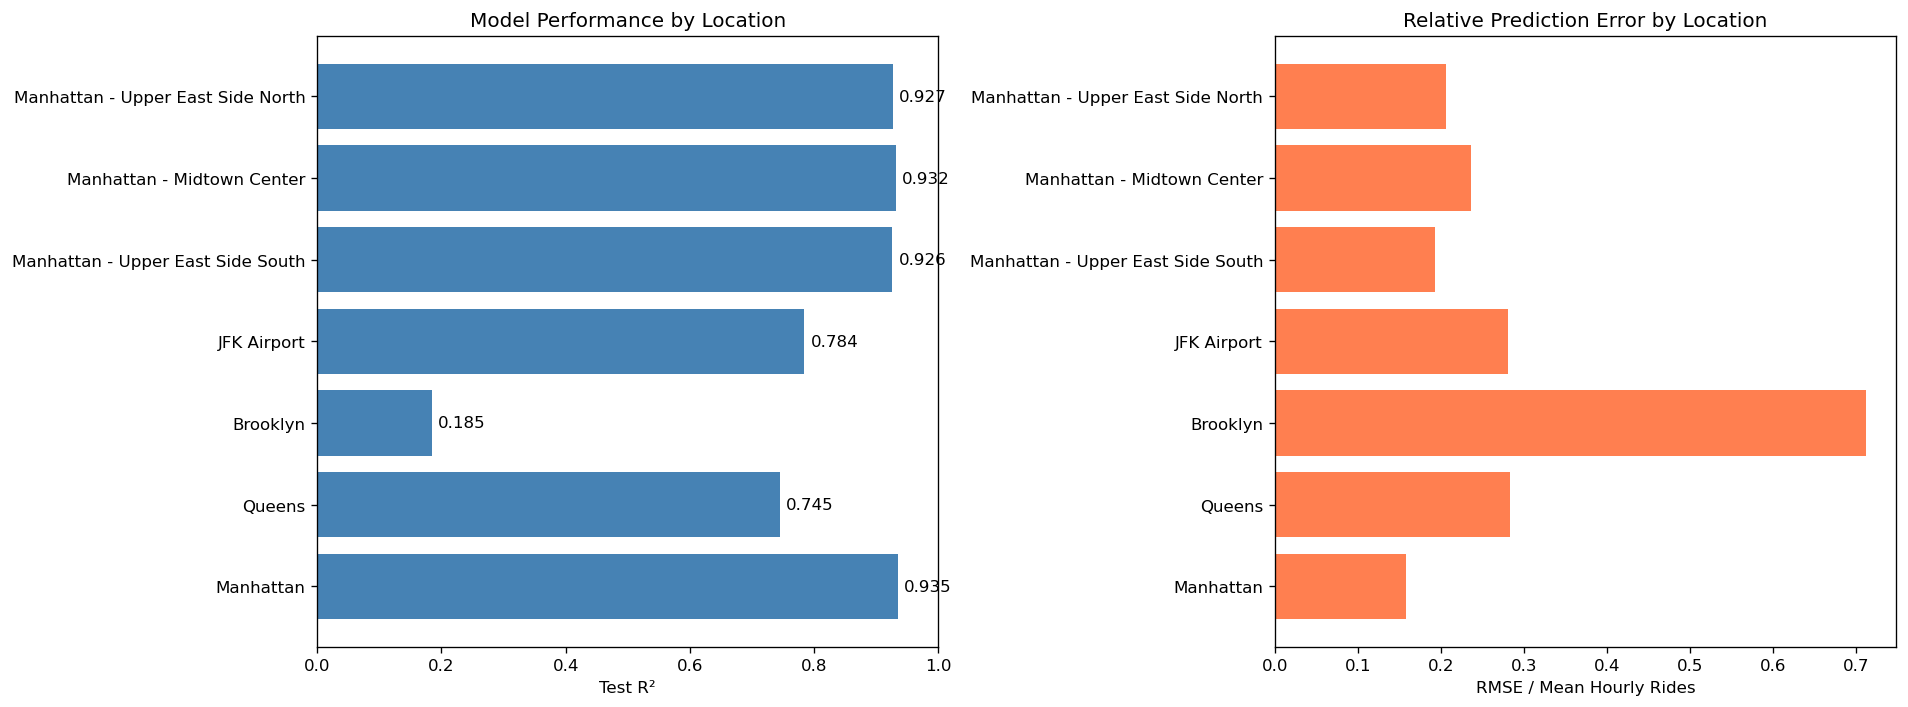

In [28]:
# Visualization: comparing locations
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# R² by location
axes[0].barh(loc_results_df['Location'], loc_results_df['Test R²'], color='steelblue')
axes[0].set_xlabel('Test R²')
axes[0].set_title('Model Performance by Location')
axes[0].set_xlim(0, 1)
for i, v in enumerate(loc_results_df['Test R²']):
    axes[0].text(v + 0.01, i, f'{v:.3f}', va='center')

# Normalized RMSE (RMSE / mean rides)
loc_results_df['Normalized RMSE'] = loc_results_df['Test RMSE'] / loc_results_df['Mean Hourly Rides'].clip(lower=1)
axes[1].barh(loc_results_df['Location'], loc_results_df['Normalized RMSE'], color='coral')
axes[1].set_xlabel('RMSE / Mean Hourly Rides')
axes[1].set_title('Relative Prediction Error by Location')

plt.tight_layout()
plt.savefig('results/location_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

The cross-location comparison reveals how model performance varies with location characteristics. Higher-volume locations like Manhattan provide more stable training data, while lower-volume or more variable locations (like JFK Airport) may show different performance patterns due to their unique demand drivers (flight schedules vs. commuting patterns).

### So What? Applying Our Model to a Real Decision

Our analysis established that temporal features predict taxi demand with R² > 0.92 for high-volume Manhattan zones. But what does this actually mean for someone trying to get around the city? Let's use our model to answer a practical question.

**Scenario**: It's a typical Friday night and you're heading to a Broadway show near Times Square. You need to catch a taxi sometime between 5 and 10 PM. When should you step outside to face the *least* competition for cabs — meaning shorter waits and a smoother pickup?

We'll also compare Friday to Saturday, so you can decide which night is better for your plans.

Times Sq/Theatre District: 2160 rows, mean rides/hr = 159, total rides = 343,605


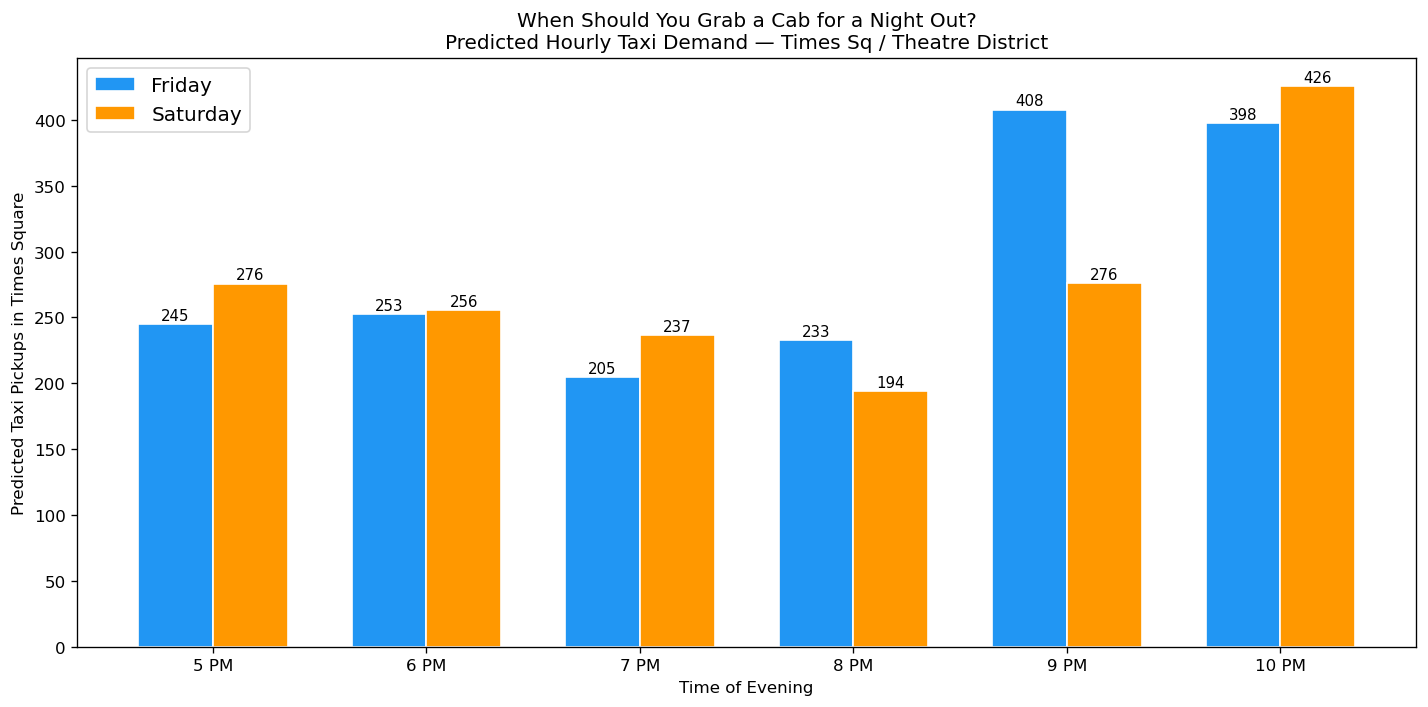

  YOUR TAXI STRATEGY FOR TIMES SQUARE

  FRIDAY
    Best time to grab a cab:  7 PM  (~205 pickups)
    Worst time (most busy):   9 PM  (~408 pickups)
    → 50% less competition at the best time!

  SATURDAY
    Best time to grab a cab:  8 PM  (~194 pickups)
    Worst time (most busy):   10 PM  (~426 pickups)
    → 54% less competition at the best time!


In [29]:
# Build a temporal-only RF model for Times Square
ts_zone_id = 230
ts_hourly = build_hourly_dataset(df, 'PULocationID', ts_zone_id, weather_daily,
                                 label="Times Sq/Theatre District")
ts_hourly = ts_hourly.sort_values(['date', 'hour']).reset_index(drop=True)

tree_feats = ['hour', 'is_holiday', 'is_weekend'] + \
             [c for c in ts_hourly.columns if c.startswith('dow_')]

ts_model = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
ts_model.fit(ts_hourly[tree_feats], ts_hourly['ride_count'])

# Predict demand for Friday vs Saturday, 5–10 PM
hours = list(range(17, 23))
hour_labels = [f'{h % 12 or 12} PM' for h in hours]

def predict_scenario(model, feats, hour, day_of_week, is_holiday=0):
    """Predict demand for a single hour/day scenario."""
    row = {f: 0 for f in feats}
    row['hour'] = hour
    row['is_holiday'] = is_holiday
    row['is_weekend'] = 1 if day_of_week in ('Saturday', 'Sunday') else 0
    dow_col = f'dow_{day_of_week}'
    if dow_col in feats:
        row[dow_col] = 1
    return model.predict(pd.DataFrame([row])[feats])[0]

friday_preds  = [predict_scenario(ts_model, tree_feats, h, 'Friday')  for h in hours]
saturday_preds = [predict_scenario(ts_model, tree_feats, h, 'Saturday') for h in hours]

# Grouped bar chart
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(hours))
width = 0.35

bars_fri = ax.bar(x - width/2, friday_preds, width,
                  label='Friday', color='#2196F3', edgecolor='white')
bars_sat = ax.bar(x + width/2, saturday_preds, width,
                  label='Saturday', color='#FF9800', edgecolor='white')

ax.set_xlabel('Time of Evening')
ax.set_ylabel('Predicted Taxi Pickups in Times Square')
ax.set_title('When Should You Grab a Cab for a Night Out?\nPredicted Hourly Taxi Demand — Times Sq / Theatre District')
ax.set_xticks(x)
ax.set_xticklabels(hour_labels)
ax.legend(fontsize=12)

for bars, preds in [(bars_fri, friday_preds), (bars_sat, saturday_preds)]:
    for bar, pred in zip(bars, preds):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{pred:.0f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Print recommendation
fri_best_h = hours[np.argmin(friday_preds)]
fri_worst_h = hours[np.argmax(friday_preds)]
sat_best_h = hours[np.argmin(saturday_preds)]
sat_worst_h = hours[np.argmax(saturday_preds)]

print("=" * 55)
print("  YOUR TAXI STRATEGY FOR TIMES SQUARE")
print("=" * 55)
print(f"\n  FRIDAY")
print(f"    Best time to grab a cab:  {fri_best_h % 12 or 12} PM  "
      f"(~{min(friday_preds):.0f} pickups)")
print(f"    Worst time (most busy):   {fri_worst_h % 12 or 12} PM  "
      f"(~{max(friday_preds):.0f} pickups)")
print(f"    → {(1 - min(friday_preds)/max(friday_preds)):.0%} less competition "
      f"at the best time!")
print(f"\n  SATURDAY")
print(f"    Best time to grab a cab:  {sat_best_h % 12 or 12} PM  "
      f"(~{min(saturday_preds):.0f} pickups)")
print(f"    Worst time (most busy):   {sat_worst_h % 12 or 12} PM  "
      f"(~{max(saturday_preds):.0f} pickups)")
print(f"    → {(1 - min(saturday_preds)/max(saturday_preds)):.0%} less competition "
      f"at the best time!")

![Alt text](pigeon_nyc_passenger.png)

This simple demonstration shows why temporal demand prediction matters beyond academic interest. A model trained only on hour and day of week — no fancy features, no real-time data — can give actionable advice about *when* to hail a cab. Riders can avoid the rush, drivers can position themselves in high-demand windows, and fleet operators can allocate vehicles where they're needed most. The same logic scales to any high-volume zone in our dataset.

## Ethics

Our analysis raises several ethical considerations that we address using the [Deon ethics checklist](http://deon.drivendata.org/):

**A.1 Informed Consent**: The TLC trip data is collected automatically through taxi meters without explicit per-ride consent from passengers. However, the data is anonymized — it contains no personally identifiable information about riders, and locations are aggregated to zone level (not GPS coordinates), providing a reasonable privacy protection.

**A.2 Collection Bias**: Our dataset only covers NYC yellow taxis, excluding green taxis (which serve outer boroughs), rideshare services (Uber, Lyft), public transit, cycling, and walking. This means our "demand" metric only captures one mode of transportation. Any policy recommendations based on this analysis would need to account for these missing modes. Additionally, our weather data comes from a single station (Central Park), which may not represent conditions at JFK Airport or Staten Island.

**C.1 Missing Perspectives**: We cannot observe unmet demand — people who wanted a taxi but couldn't find one. Our models predict observed, supply-constrained demand, not true underlying transportation need. This distinction matters for any operational use of these predictions.

**C.2 Dataset Bias**: Manhattan accounts for ~89% of all yellow taxi pickups. Our models naturally perform best for Manhattan and may underserve areas with less data. This spatial imbalance mirrors real-world resource allocation patterns that concentrate services in wealthy, dense urban cores.

**D.1 Proxy Discrimination**: Pickup zone is our most powerful spatial feature, but zones in NYC correlate strongly with race and income due to residential segregation. If location-specific demand predictions were used for fleet allocation, they could perpetuate existing inequities — directing more taxis to affluent neighborhoods and fewer to underserved communities.

**D.3 Metric Selection**: We optimize for R² and RMSE, which treat over-prediction and under-prediction symmetrically. In practice, these errors have different costs: under-predicting demand means passengers can't find rides, while over-predicting means idle drivers. An operationally fair model would use asymmetric loss functions.

**D.5 Communicating Limitations**: Our model is trained on only 90 days of winter data (December–February). Taxi demand patterns differ substantially across seasons (tourism, weather, events). These predictions should not be extrapolated beyond the winter period or used for production fleet management without year-round training data.

## Discussion and Conclusion

Our project set out to predict NYC yellow taxi demand using temporal and weather features, and to determine which feature type is most important for forecasting. Through a systematic analysis pipeline, we arrived at several key findings.

**Temporal features dominate prediction.** Across all locations and model types, hour of day was consistently the most important feature. A Random Forest using only temporal features (hour, day of week, holiday, weekend indicators) achieved R² ≈ 0.95 on the Manhattan test set — meaning temporal patterns explain the vast majority of hourly demand variance. This strongly confirms the finding from Moreira-Matias et al. (2013) that taxi demand follows predictable temporal cycles.

**Weather provides no meaningful improvement.** Contrary to Singhal et al. (2014), who found precipitation significantly increased taxi demand, our analysis shows that adding daily weather features actually slightly *decreased* model performance. A paired t-test on cross-validation folds confirmed the difference is not statistically significant (p > 0.05). There are several possible explanations: (1) our weather data is daily rather than hourly, so within-day weather changes like afternoon rain are invisible to the model; (2) our winter study period may not have enough temperature variation to shift behavior; and (3) the effect found by Singhal et al. may operate through mechanisms we don't observe (e.g., subway disruptions during storms).

**Cross-location generalization varies with volume.** High-volume locations showed excellent performance: Manhattan and its top sub-zones (R² > 0.92), while JFK Airport achieved moderate performance (R² ≈ 0.78), likely because airport demand is partly driven by flight schedules that our temporal features approximate but don't fully capture. Brooklyn performed poorly (R² ≈ 0.19) because with very few rides per hour on average, the signal-to-noise ratio is too low for reliable prediction. This demonstrates that our approach works best for locations with sufficient demand volume.

**The dimensionality solution works.** Our location-specific modeling approach successfully resolved the dimensionality mismatch identified in the EDA. By aggregating trips into hourly counts for specific locations, we created datasets where temporal and weather features naturally align, providing ~2,160 observations per location — far more than the 90 daily observations available for weather-only models. This is a key methodological insight: different feature types predict at different spatiotemporal granularities, and aligning them requires fixing some dimensions.

**Limitations.** Several limitations constrain the generalizability of our findings: (1) Only 90 days of winter data — we cannot capture seasonal patterns, summer tourism, or annual events. (2) A single weather station in Central Park — localized weather differences across boroughs are invisible. (3) Only yellow taxis — the complete NYC transportation picture requires Uber, Lyft, green taxis, and public transit data. (4) No event data — concerts, sports games, and conferences drive demand spikes we cannot predict. (5) Daily weather granularity — hourly weather observations from NOAA might reveal within-day effects that our daily averages miss. (6) The test set covers only 14 days (Feb 15–28), which may not capture all weekly patterns.

**Future work.** If this project were to continue, we would (1) extend to a full year of data to capture seasonality, (2) incorporate hourly weather observations from NOAA, (3) add event data from venues like Madison Square Garden and flight arrival data for JFK, (4) explore time-series specific models like Prophet or LSTM networks that can natively capture trends and autocorrelation, and (5) combine yellow taxi data with Uber/Lyft trip records (available from TLC) for a complete rideshare demand picture.

In conclusion, temporal features — particularly hour of day — are the dominant driver of NYC taxi demand, explaining the vast majority of hourly variation at any location. Weather contributes no statistically significant improvement at the daily level. Location-specific Random Forest models provide an effective and interpretable framework for demand prediction, achieving R² > 0.92 for high-volume locations.